In [319]:
import pandas as pd

# Load from a CSV file
df = pd.read_csv("../data/sales_group6.csv")
df.head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [320]:
#Data exploration
print(df.info())
df["state_holiday"].value_counts()  #state holiday column has 4 unique values: 0, a, b, c. 0 
df["open"].value_counts()  
df["promotion"].value_counts()  
df["school_holiday"].value_counts()  
df["day_of_week"].value_counts()  

df.groupby('day_of_week')['sales'].sum().sort_index()

<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 48.9 MB
None


day_of_week
1    710735222
2    642240264
3    600804432
4    575319834
5    619762820
6    534382948
7     19187721
Name: sales, dtype: int64

In [321]:
df_plot = X_train_clean.copy()
df_plot['sales'] = y_train.values

print(df_plot.groupby(['day_of_week', 'promotion'])['sales'].sum())

day_of_week  promotion
1            0            165096518
             1            332934132
2            0            167876238
             1            281437914
3            0            161889754
             1            256578881
4            0            153290376
             1            249778782
5            0            186433985
             1            247747696
6            0            374181481
7            0             13436308
Name: sales, dtype: int64


## Correlation

<Axes: >

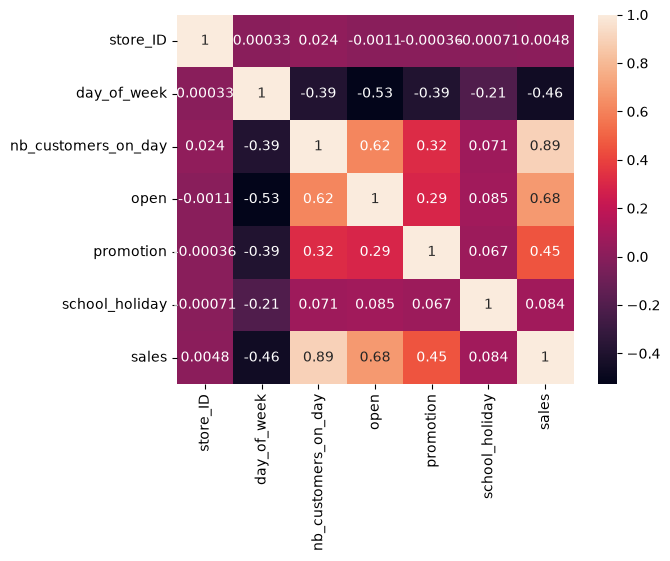

In [322]:
import seaborn as sns

sns.heatmap(df.drop(columns="Unnamed: 0").select_dtypes("number").corr(), annot=True)

<Axes: >

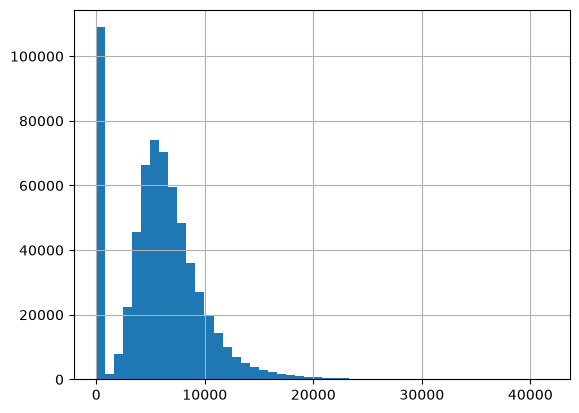

In [323]:
df["sales"].hist(bins=50)

In [324]:
df.select_dtypes("number").corr()["sales"].sort_values()

day_of_week           -0.461107
Unnamed: 0            -0.000880
store_ID               0.004804
school_holiday         0.084484
promotion              0.451819
open                   0.678463
nb_customers_on_day    0.894872
sales                  1.000000
Name: sales, dtype: float64

In [325]:
df.sample(20)

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
638265,637639,832,2,2014-11-04,591,1,1,0,0,7573
158239,178218,315,3,2013-07-31,656,1,1,0,1,7637
181752,12831,917,5,2014-01-24,916,1,1,0,0,7679
191397,674441,249,5,2014-05-09,657,1,1,0,0,6148
190361,387983,690,6,2014-05-24,646,1,0,0,0,4262
415046,46918,401,1,2013-05-06,705,1,0,0,0,6459
329965,601045,846,4,2013-01-10,893,1,1,0,0,10156
463151,226079,284,5,2013-05-03,491,1,1,0,0,5547
575617,268015,87,1,2013-01-21,913,1,1,0,0,8221
394478,480154,3,7,2015-01-25,0,0,0,0,0,0


## Data split

In [326]:
import Data_preparation 
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

(640840, 9) (448588, 9) (96126, 9) (96126, 9) (640840,)


## Data Cleaning

In [327]:
X_train_clean, X_val_clean, X_test_clean = clean_splits(X_train, X_val, X_test)

Unnamed: 0 in X_train_clean: False
Unnamed: 0 in X_val_clean: False
Unnamed: 0 in X_test_clean: False
state_hol_0    434837
state_hol_1      8949
state_hol_2      2955
state_hol_3      1847
dtype: int64


In [328]:
X_train_clean

,day_of_week,nb_customers_on_day,open,promotion,school_holiday,state_hol_0,state_hol_1,state_hol_2,state_hol_3
439297,2,658,1,0,0,1,0,0,0
326963,6,533,1,0,0,1,0,0,0
348005,4,650,1,0,0,1,0,0,0
270031,1,754,1,1,0,1,0,0,0
106547,6,1065,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...
110268,4,1040,1,0,1,1,0,0,0
259178,1,714,1,1,0,1,0,0,0
365838,4,0,0,0,1,0,1,0,0
131932,5,0,0,1,1,0,0,1,0


In [329]:
X_train_sc, X_val_sc, X_test_sc, scaler = scale_splits(X_train_clean, X_val_clean, X_test_clean)

   day_of_week  nb_customers_on_day      open  promotion  school_holiday  \
0    -1.002075             0.053358  0.452688  -0.785771       -0.465597   
1     1.000484            -0.215777  0.452688  -0.785771       -0.465597   
2    -0.000796             0.036133  0.452688  -0.785771       -0.465597   
3    -1.502715             0.260054  0.452688   1.272635       -0.465597   
4     1.000484             0.929662  0.452688  -0.785771       -0.465597   

   state_hol_0  state_hol_1  state_hol_2  state_hol_3  
0      0.17783    -0.142672    -0.081431    -0.064299  
1      0.17783    -0.142672    -0.081431    -0.064299  
2      0.17783    -0.142672    -0.081431    -0.064299  
3      0.17783    -0.142672    -0.081431    -0.064299  
4      0.17783    -0.142672    -0.081431    -0.064299  


In [330]:
cleaning_summary = pd.DataFrame({
    
    '_dtype': [
        X_train_clean['day_of_week'].dtype,
        X_val_clean['day_of_week'].dtype,
        X_test_clean['day_of_week'].dtype
    ],
    'missing_dayOfTheWeek': [
        X_train_clean['day_of_week'].isna().sum(),
        X_val_clean['day_of_week'].isna().sum(),
        X_test_clean['day_of_week'].isna().sum()
    ]
}, index=['train', 'validation', 'test'])

cleaning_summary

,_dtype,missing_dayOfTheWeek
train,int64,0
validation,int64,0
test,int64,0


## Dummy model

In [331]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score

# 1. create the model
baseline = DummyRegressor(strategy="mean")

# 2. train it (learns the average sales in train)
baseline.fit(X_train_clean, y_train)

# 3. predict (the same average for every validation row)
y_val_pred = baseline.predict(X_val_clean)

# 4. score
baseline_r2 = r2_score(y_val, y_val_pred)
print(f"Baseline R² (validation): {baseline_r2:.4f}")

Baseline R² (validation): -0.0000


## Linear regression

In [332]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_sc, y_train)                 # scaled data

print(f"Train R²: {r2_score(y_train, lin_reg.predict(X_train_sc)):.4f}")
print(f"Val R²:   {r2_score(y_val, lin_reg.predict(X_val_sc)):.4f}")

Train R²: 0.8538
Val R²:   0.8519


## Decision Tree

In [333]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=10, random_state=42)
tree.fit(X_train_sc, y_train)                 # scaled data

print(f"Train R²: {r2_score(y_train, tree.predict(X_train_sc)):.4f}")
print(f"Val R²:   {r2_score(y_val, tree.predict(X_val_sc)):.4f}")

Train R²: 0.8783
Val R²:   0.8741


## Random Forest

In [334]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(n_estimators=20, n_jobs=-1, random_state=42)
forest.fit(X_train_sc, y_train)

print(f"Train R²: {r2_score(y_train, forest.predict(X_train_sc)):.4f}")
print(f"Val R²:   {r2_score(y_val, forest.predict(X_val_sc)):.4f}")

Train R²: 0.9009
Val R²:   0.8580


## XG Boost

In [335]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, random_state=42)
xgb.fit(X_train_clean, y_train)                  # unscaled data

print(f"Train R²: {r2_score(y_train, xgb.predict(X_train_clean)):.4f}")
print(f"Val R²:   {r2_score(y_val, xgb.predict(X_val_clean)):.4f}")

Train R²: 0.8767
Val R²:   0.8737


## Hyper_params

In [336]:
tuning_results = []

for depth in [8, 10, 12, 15, 20]:
    for leaf in [1, 10, 50]:
        m = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=leaf, random_state=42)
        m.fit(X_train_sc, y_train)
        tuning_results.append({
            "max_depth": depth,
            "min_samples_leaf": leaf,
            "train_r2": r2_score(y_train, m.predict(X_train_sc)),
            "val_r2": r2_score(y_val, m.predict(X_val_sc)),
        })

tuning_df = pd.DataFrame(tuning_results)
tuning_df["gap"] = tuning_df["train_r2"] - tuning_df["val_r2"]
tuning_df.sort_values("val_r2", ascending=False).head(10)

,max_depth,min_samples_leaf,train_r2,val_r2,gap
4,10,10,0.878132,0.874759,0.003374
5,10,50,0.877408,0.874351,0.003057
3,10,1,0.878294,0.874057,0.004237
8,12,50,0.878649,0.874044,0.004605
11,15,50,0.879646,0.873344,0.006303
7,12,10,0.880287,0.873332,0.006955
1,8,10,0.875221,0.873222,0.001999
0,8,1,0.875230,0.873214,0.002016
14,20,50,0.879894,0.873136,0.006758
2,8,50,0.874974,0.872908,0.002066


## Evaluation

In [337]:
final_tree = DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, random_state=42)
final_tree.fit(X_train_sc, y_train)

test_r2 = r2_score(y_test, final_tree.predict(X_test_sc))
print(f"Test R²: {test_r2:.4f}")

Test R²: 0.8724


## Prediction

In [338]:

with open("../group6.txt", "w") as f:
    f.write(f"{test_r2:.4f}")

## Export

In [339]:
import pickle
with open("../models/decision_tree.pkl", "wb") as f:
    pickle.dump(final_tree, f)